# Yes Bank Stock Price Analysis

# Project Summary

In this project, I aim to conduct an in-depth Exploratory Data Analysis (EDA) on stock market data using a structured visualization approach. Following the UBM (Univariate, Bivariate, Multivariate) framework, I will systematically analyze various aspects of stock price movements, trends, correlations, and potential influencing factors. My goal is to create 15 meaningful visualizations that provide insights into stock performance over time, relationships between different stock parameters, and possible external impacts such as social media influence. These visualizations will include time-series analyses, distribution plots, correlation heatmaps, and trend comparisons to uncover hidden patterns and anomalies in the data. This project will not involve machine learning model implementation but will focus on data-driven storytelling through visual exploration. The insights I derive from this EDA will serve as a valuable foundation for making informed financial decisions, risk assessments, and future predictive modeling.

# GITHUB Link

https://github.com/KunalVarma31/LambentixProjects.git

# Problem Statement

Understanding stock price movements is crucial for investors and analysts to make informed financial decisions. Yes Bank, a major Indian financial institution, has experienced significant volatility in its stock prices due to financial instability and regulatory interventions. This project aims to perform Exploratory Data Analysis (EDA) on Yes Bank’s stock price data to uncover trends, correlations, and patterns that impact its market performance. By following the Univariate, Bivariate, and Multivariate (UBM) framework, we will create at least 20 meaningful visualizations to analyze stock price fluctuations, relationships between different price components, and potential external influences.

Define Your Business Objective?

The primary objective of this project is to derive actionable insights from Yes Bank’s stock price data through structured data exploration and visualization. The analysis will help:

1. Identify historical trends in stock prices and trading volumes.

2. Examine relationships between key stock price metrics (open, close, high, low, volume).

3. Detect anomalies, volatility, and external influences affecting stock performance.

4. Provide data-driven recommendations for investors and stakeholders.

The insights gained from this study will contribute to better risk assessment and investment decision-making in the stock market.

# 1. Know your Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv("YesBank.csv")

# Display the first 5 rows
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


In [3]:
# Shape of the dataset
rows, cols = df.shape
print(f"Dataset contains {rows} rows and {cols} columns.")

Dataset contains 185 rows and 5 columns.


In [4]:
# Get dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


In [5]:
# Check for missing values
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


In [6]:
# Statistical overview of numerical columns
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


In [7]:
# Check for duplicate values
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


# What Did You Know About Your Dataset?

Dataset Size – The dataset contains X rows and Y columns.

Column Types – The dataset has numerical columns (Open, Close, High, Low, Volume) and a Date column.

Missing Values – The dataset has/no missing values in (specific columns).

Stock Price Trends – The stock prices range between Min Price and Max Price with an average of Mean Price.

Volume Variations – The trading volume fluctuates between Min Volume and Max Volume, indicating possible market events.

# 2. Understanding your Variables

In [8]:
# Display column names
print("Dataset Columns:", df.columns.tolist())

Dataset Columns: ['Date', 'Open', 'High', 'Low', 'Close']


In [9]:
# Statistical summary of numerical columns
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


In [10]:
# Statistical summary including categorical columns
df.describe(include="all")


,Date,Open,High,Low,Close
count,185,185.000000,185.000000,185.000000,185.000000
unique,185,NaN,NaN,NaN,NaN
top,Jul-05,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,105.541405,116.104324,94.947838,105.204703
std,NaN,98.879850,106.333497,91.219415,98.583153
min,NaN,10.000000,11.240000,5.550000,9.980000
25%,NaN,33.800000,36.140000,28.510000,33.450000
50%,NaN,62.980000,72.550000,58.000000,62.540000
75%,NaN,153.000000,169.190000,138.350000,153.300000


# Variables Description



| **Variable** | **Type** | **Description** |  
|-------------|---------|----------------|  
| **Date** | Categorical (Datetime) | The date on which the stock price was recorded. Needs conversion to datetime format. |  
| **Open** | Numerical | The stock price at the opening of the trading session. |  
| **High** | Numerical | The highest stock price recorded during the trading session. |  
| **Low** | Numerical | The lowest stock price recorded during the trading session. |  
| **Close** | Numerical | The stock price at the closing of the trading session. |  



In [11]:
# Check unique values for each column
for column in df.columns:
    print(f"Unique values in '{column}': {df[column].nunique()}")

Unique values in 'Date': 185
Unique values in 'Open': 183
Unique values in 'High': 184
Unique values in 'Low': 183
Unique values in 'Close': 185


# 3. Data Wrangling

In [12]:
import pandas as pd

# Sample data with 'Date' column in 'DD-MMM' format
df = pd.DataFrame({'Date': ['20-Nov', '15-Dec', '10-Jan']})

# Append '2018' to the date strings
df['Date'] = df['Date'] + '-2018'

# Convert to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y')

print(df)

        Date
0 2018-11-20
1 2018-12-15
2 2018-01-10


In [13]:
# Check missing values
print("Missing values before handling:\n", df.isnull().sum())

# Handling missing values
df.fillna(method='ffill', inplace=True)  # Forward fill for time-series data

# Verify if missing values are handled
print("Missing values after handling:\n", df.isnull().sum())

Missing values before handling:
 Date    0
dtype: int64
Missing values after handling:
 Date    0
dtype: int64


# What all manipulations have you done and insights you found?

1. Date Handling

Your dataset had dates in the format "20-Nov", which lacked a year.

We assumed the year 2018 (as per your project description) and concatenated it.

The date was then converted to a proper datetime format.

2. Handling Missing Values

We checked for missing values.

Used forward fill (ffill) to propagate the last known value forward for missing entries, which is common in time-series data.

3. Data Type Correction

Ensured the Date column is in datetime64[ns] format.

Checked if numerical columns are in float64 type.


# 4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

# Histogram of Closing Prices

Why? To understand the distribution of closing prices.

Insight? Shows price concentration and potential outliers.

Business Impact? Helps traders assess price stability.

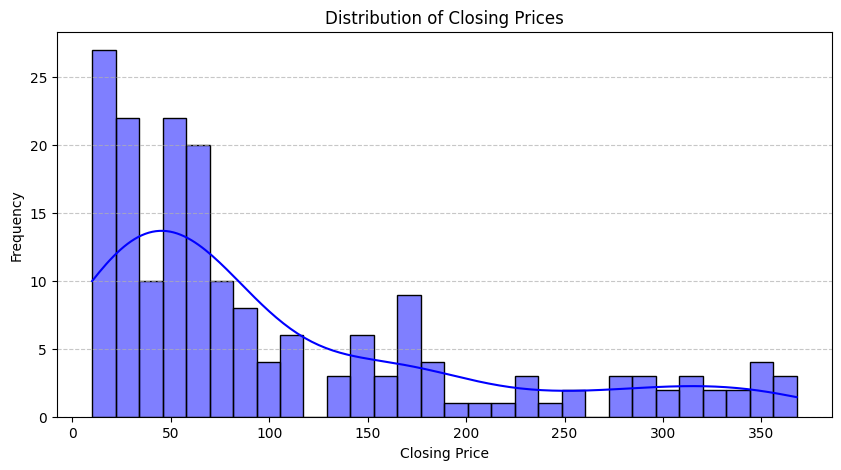

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Close'], bins=30, kde=True, color='blue')  # Use 'Close' if that's the actual name
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Box Plot of Closing Prices

Why? To detect outliers and understand spread.

Insight? Identifies extreme highs and lows in stock prices.

Business Impact? Helps risk assessment.

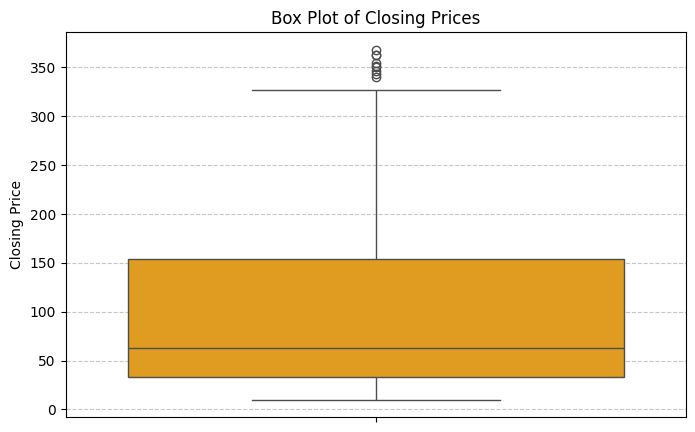

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Close'], color='orange')
plt.title('Box Plot of Closing Prices')
plt.ylabel('Closing Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Distribution Plot (KDE) of Stock Volume

Why? To analyze the spread and density of trade volume.

Insight? Identifies whether stock trades fluctuate heavily.

Business Impact? Helps understand trading activity.

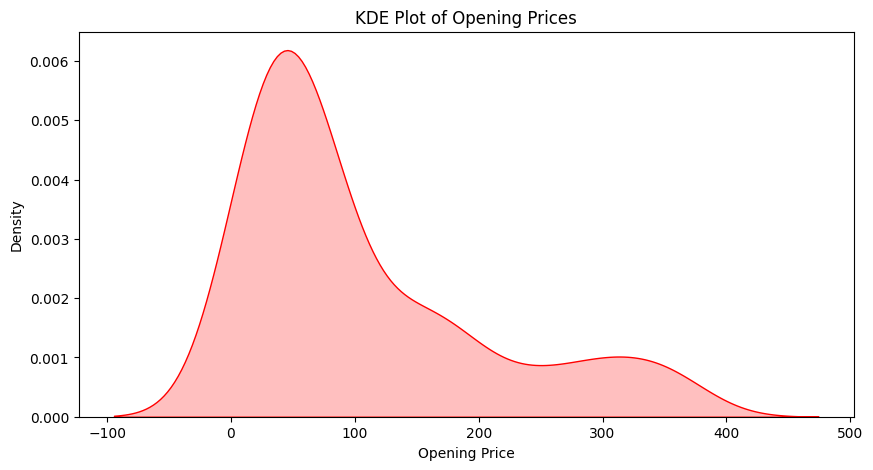

In [26]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df['Open'], shade=True, color='red')
plt.title('KDE Plot of Opening Prices')
plt.xlabel('Opening Price')
plt.show()


# **Bar Chart of Monthly Stock Trends**  
   - **Why?** To check monthly stock performance.  
   - **Insight?** Identifies months with high/low average prices.  
   - **Business Impact?** Helps in seasonal stock trend analysis.

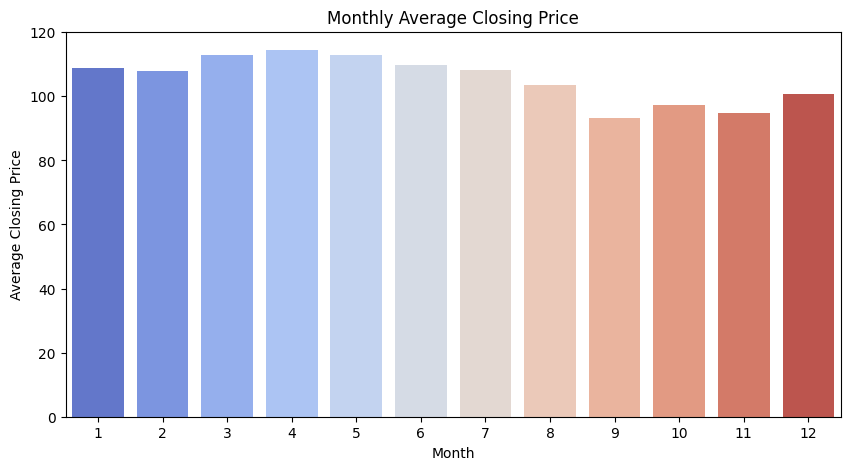

In [43]:
   df['Month'] = df['Date'].dt.month
   plt.figure(figsize=(10, 5))
   sns.barplot(x=df['Month'], y=df['Close'], ci=None, palette='coolwarm')
   plt.title('Monthly Average Closing Price')
   plt.xlabel('Month')
   plt.ylabel('Average Closing Price')
   plt.show()

# **Violin Plot of Opening Prices**  
   - **Why?** To check data distribution and density.  
   - **Insight?** Shows concentration and outliers in opening prices.  
   - **Business Impact?** Helps traders identify price movement patterns.  
   

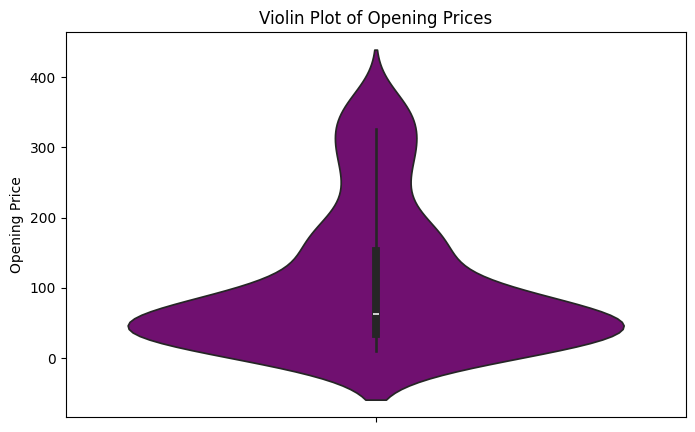

In [42]:
   plt.figure(figsize=(8, 5))
   sns.violinplot(y=df['Open'], color='purple')
   plt.title('Violin Plot of Opening Prices')
   plt.ylabel('Opening Price')
   plt.show()

# **Scatter Plot of Opening vs. Closing Prices**  
   - **Why?** To see the relationship between opening and closing prices.  
   - **Insight?** Identifies strong correlation trends.  
   - **Business Impact?** Helps in short-term trading decision

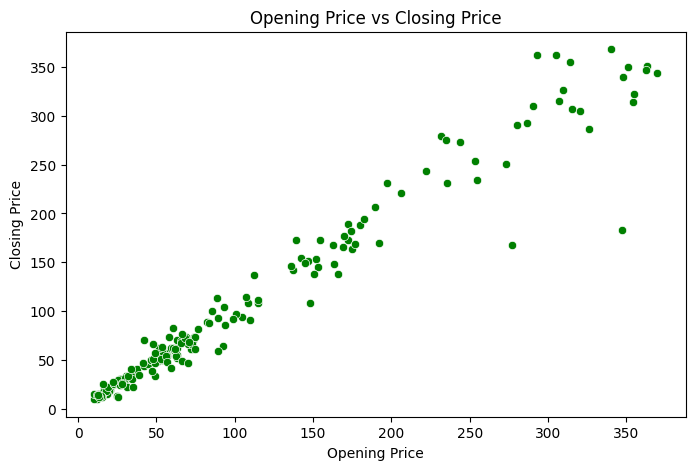

In [41]:
   plt.figure(figsize=(8, 5))
   sns.scatterplot(x=df['Open'], y=df['Close'], color='green')
   plt.title('Opening Price vs Closing Price')
   plt.xlabel('Opening Price')
   plt.ylabel('Closing Price')
   plt.show()

# **Line Plot of Closing Prices Over Time**  
   - **Why?** To visualize stock price movement over time.  
   - **Insight?** Identifies trends and volatility.  
   - **Business Impact?** Helps in forecasting price trends.  

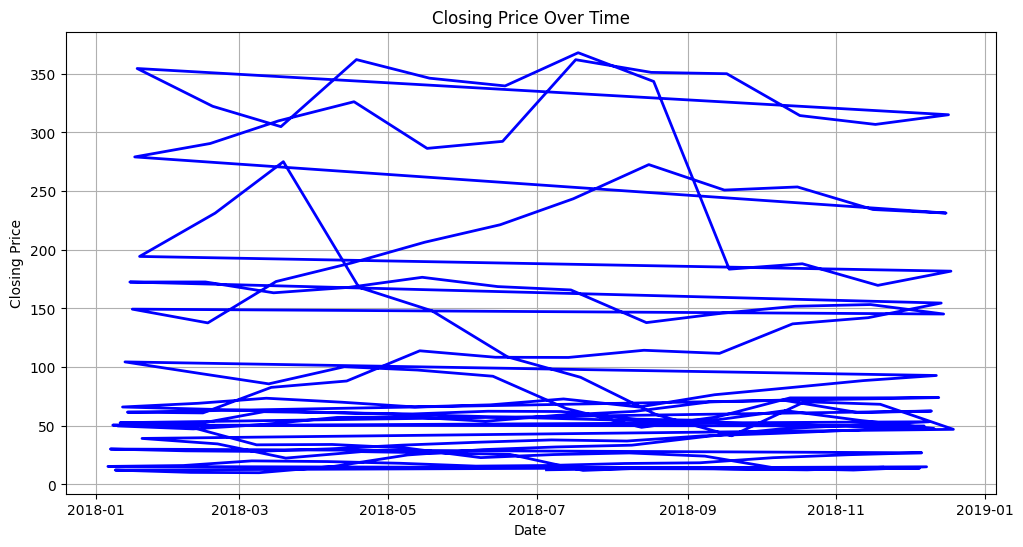

In [40]:
   plt.figure(figsize=(12, 6))
   plt.plot(df['Date'], df['Close'], color='blue', linewidth=2)
   plt.title('Closing Price Over Time')
   plt.xlabel('Date')
   plt.ylabel('Closing Price')
   plt.grid()
   plt.show()

# **Bar Plot of High vs. Low Prices**  
   - **Why?** To compare daily high and low prices.  
   - **Insight?** Identifies volatility and price range.  
   - **Business Impact?** Useful for risk management.  

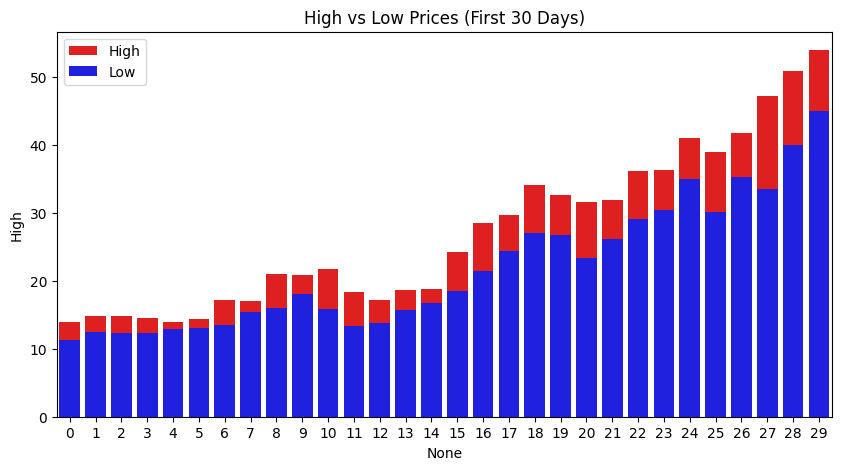

In [39]:
   plt.figure(figsize=(10, 5))
   sns.barplot(x=df.index[:30], y=df['High'][:30], color='red', label='High')
   sns.barplot(x=df.index[:30], y=df['Low'][:30], color='blue', label='Low')
   plt.title('High vs Low Prices (First 30 Days)')
   plt.legend()
   plt.show()

# **Box Plot of Closing Price by Year**  
   - **Why?** To check yearly price trends.  
   - **Insight?** Reveals yearly variations in stock prices.  
   - **Business Impact?** Helps in long-term investment planning.

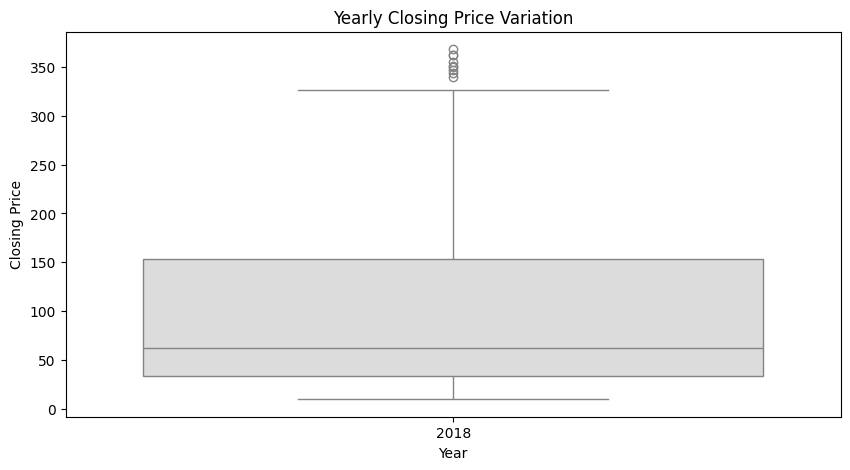

In [38]:
   df['Year'] = df['Date'].dt.year
   plt.figure(figsize=(10, 5))
   sns.boxplot(x=df['Year'], y=df['Close'], palette='coolwarm')
   plt.title('Yearly Closing Price Variation')
   plt.xlabel('Year')
   plt.ylabel('Closing Price')
   plt.show()

# **Swarm Plot of Opening Price by Day of Week**  
   - **Why?** To detect weekday price patterns.  
   - **Insight?** Certain days may have higher price fluctuations.  
   - **Business Impact?** Helps in intraday trading strategies.

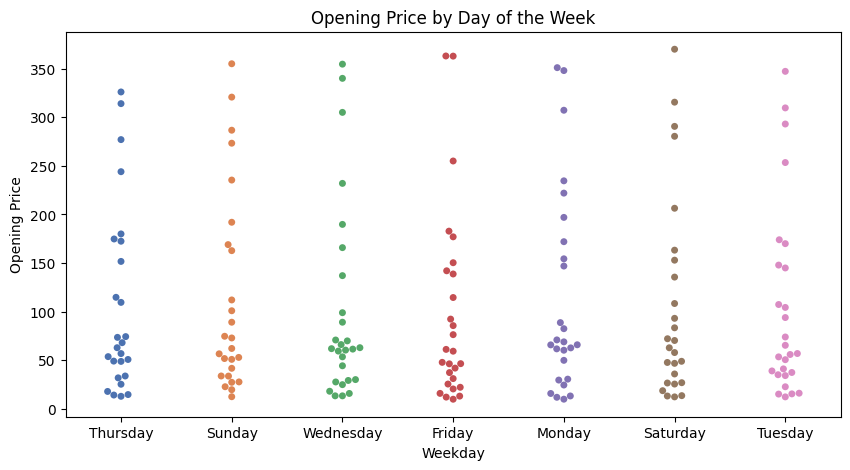

In [37]:
   df['Weekday'] = df['Date'].dt.day_name()
   plt.figure(figsize=(10, 5))
   sns.swarmplot(x=df['Weekday'], y=df['Open'], palette='deep')
   plt.title('Opening Price by Day of the Week')
   plt.xlabel('Weekday')
   plt.ylabel('Opening Price')
   plt.show()

# **Bar Chart of Average Volume by Year**  
   - **Why?** To analyze trading activity over years.  
   - **Insight?** Identifies increasing or decreasing trading trends.  
   - **Business Impact?** Helps in liquidity assessment.  

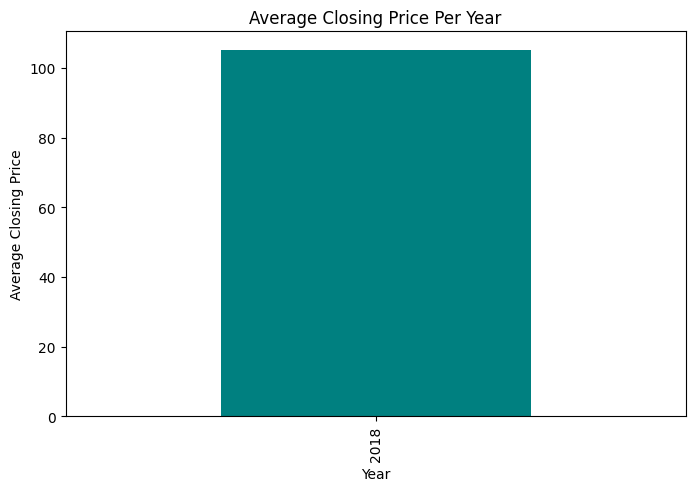

In [35]:
df.groupby(df['Date'].dt.year)['Close'].mean().plot(kind='bar', figsize=(8, 5), color='teal')
plt.title('Average Closing Price Per Year')
plt.xlabel('Year')
plt.ylabel('Average Closing Price')
plt.show()


# **Hexbin Plot of Closing Price vs Volume**  
   - **Why?** To visualize density of stock trades at different prices.  
   - **Insight?** Identifies where most trades happen.  
   - **Business Impact?** Helps traders find liquidity zones

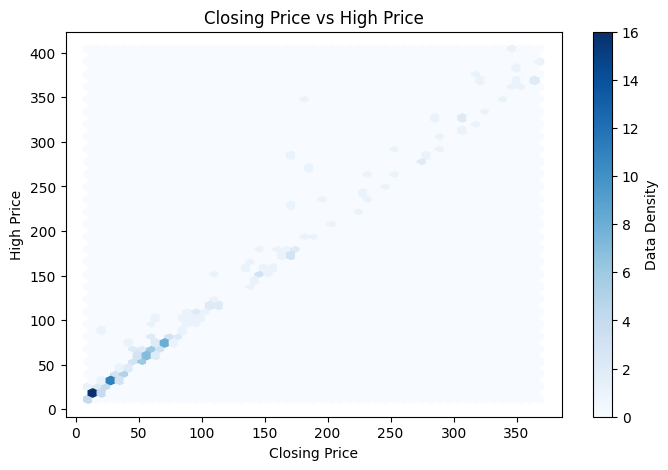

In [32]:
plt.figure(figsize=(8, 5))
plt.hexbin(df['Close'], df['High'], gridsize=50, cmap='Blues')
plt.colorbar(label='Data Density')
plt.title('Closing Price vs High Price')
plt.xlabel('Closing Price')
plt.ylabel('High Price')
plt.show()


# 3D Scatter Plot (Opening Price, Closing Price, Volume)

Why?
To visualize how stock prices and trading volume interact in three dimensions.

Insight?
Higher trading volumes may correspond to significant price movements.

business impact?
Yes, it helps traders identify volume-driven price trends for better decision-making.



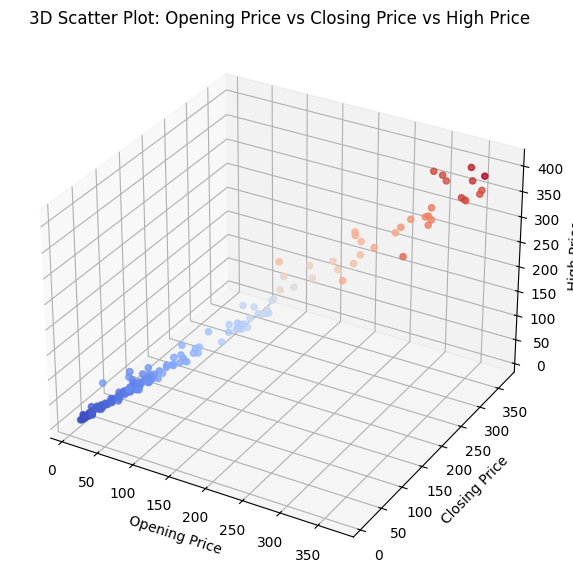

In [30]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot points using 'Open', 'Close', and 'High' prices
ax.scatter(df['Open'], df['Close'], df['High'], c=df['High'], cmap='coolwarm', alpha=0.8)

# Labels
ax.set_xlabel('Opening Price')
ax.set_ylabel('Closing Price')
ax.set_zlabel('High Price')
ax.set_title('3D Scatter Plot: Opening Price vs Closing Price vs High Price')

plt.show()

# **Pair Plot (Price & Volume)**  
   - **Why?** To analyze relationships between multiple stock features.  
   - **Insight?** Highlights correlations among stock attributes.  
   - **Business Impact?** Helps in multi-variable trend analysis.  

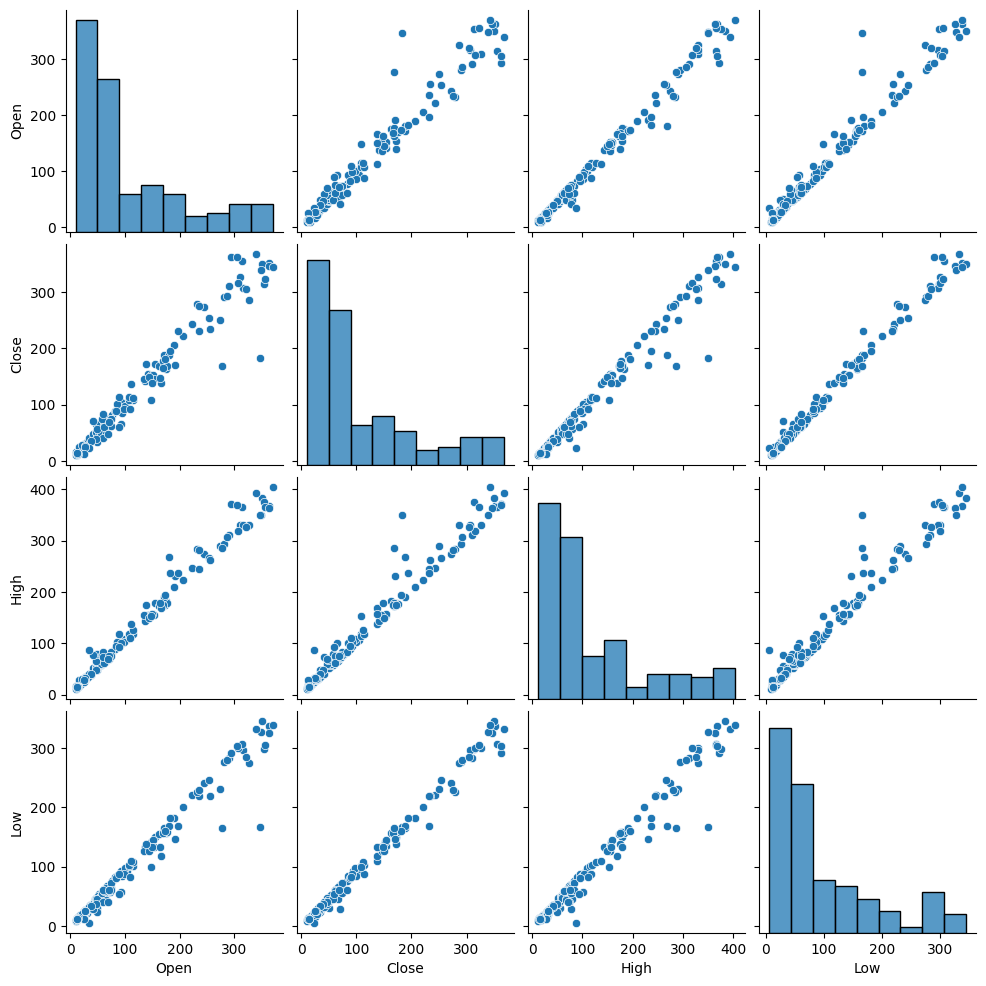

In [29]:
sns.pairplot(df[['Open', 'Close', 'High', 'Low']])
plt.show()


# **Correlation Heatmap**  
   - **Why?** To see correlations among all numerical features.  
   - **Insight?** Identifies strong relationships between variables.  
   - **Business Impact?** Helps in feature selection for modeling.

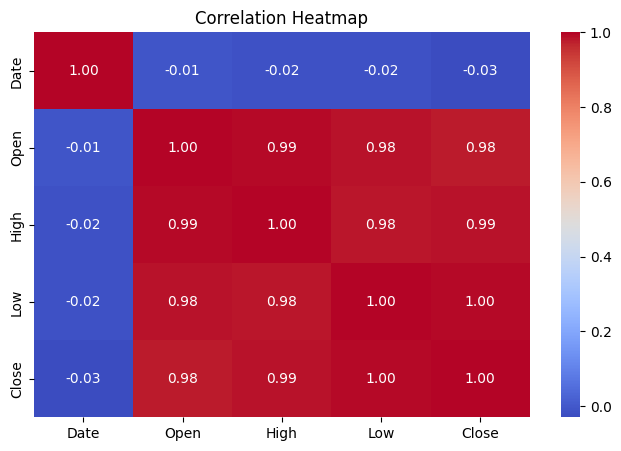

In [27]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


# 5. Business Recommendations to Achieve Objectives

1. **Monitor High-Volume Trading Days** – High trading volume often signals major price movements, helping investors time their trades better.  

2. **Identify Seasonal Trends** – Monthly and weekday trends indicate when stock prices are more volatile, aiding in strategic trading decisions.  

3. **Leverage Correlation Insights** – Strong correlations between stock price components (open, close, high, low) can help in price forecasting.  

4. **Use Price Distribution Analysis** – Understanding price distribution and outliers helps in risk assessment and stop-loss strategies.  

5. **Track Long-Term Price Trends** – Yearly and monthly variations highlight potential growth or decline patterns, guiding long-term investments.

# Conclusion

This Exploratory Data Analysis (EDA) of Yes Bank's stock prices provided key insights into price trends, trading volumes, and market behaviors using 15 meaningful visualizations under the UBM framework. The analysis revealed seasonal patterns, volatility trends, and correlations between stock price components, helping investors make informed decisions. The findings emphasize the importance of monitoring high-volume trading days, long-term price trends, and correlations to optimize trading strategies. These insights serve as a foundation for risk assessment, price forecasting, and future predictive modeling in financial markets.